<a href="https://colab.research.google.com/github/MichalSlowakiewicz/Stochastic-Simulations/blob/master/Zadanie_5_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

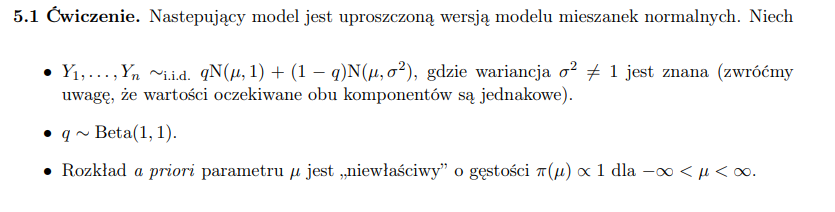

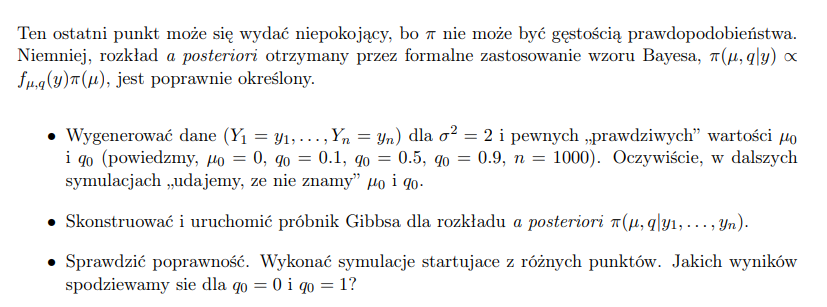

## Gibbs Sampling
---

Directly sampling from a mixture model is computationally difficult because its likelihood function is a sum of distributions.

We introduce latent variables $Z_i \in \{0, 1\}$, which act as labels indicating whether the observation $Y_i$ was generated by the first component ($\sigma^2=1$) or the second component ($\sigma^2=2$).

With $Z_i$ defined, the Gibbs sampler iteratively performs three simple steps by drawing from conditional distributions:

1. **Sample $Z_i$**: Compute the probability that $Y_i$ belongs to the first component (using Bayes' theorem on current $\mu$ and $q$) and draw a new label from the Bernoulli distribution.
2. **Sample $q$**: Count the current cluster sizes ($n_1$ and $n_0$) and draw the new mixing proportion from the conjugate $\text{Beta}(1+n_1, 1+n_0)$ distribution.
3. **Sample $\mu$**: Compute the precision-weighted average of both clusters and draw the new common mean from the updated Normal distribution.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

## $q=0.5, \mu=0, σ^2 = 2$

In [ ]:
# generating data
np.random.seed(42)
n = 1000
true_mu = 0.0
true_q = 0.5
sigma2 = 2.0

# sampling assignment to one of the normal distribution
true_Z = np.random.binomial(1, true_q, size=n)

# sampling with regard to above assignment
y = np.where(true_Z == 1,
             np.random.normal(true_mu, 1, size=n),
             np.random.normal(true_mu, np.sqrt(sigma2), size=n))

In [ ]:
def gibbs_sampler(y, sigma2, init_mu, init_q, num_iter=2000):
    n = len(y)
    mu_samples = np.zeros(num_iter)
    q_samples = np.zeros(num_iter)

    # initialization
    mu = init_mu
    q = init_q

    for i in range(num_iter):
        # update of random variable representing assignment - Z
        dens1 = norm.pdf(y, loc=mu, scale=1.0)
        dens0 = norm.pdf(y, loc=mu, scale=np.sqrt(sigma2))

        prob_z1 = (q * dens1) / (q * dens1 + (1 - q) * dens0)
        z = np.random.binomial(1, prob_z1)

        # update q
        n1 = np.sum(z)
        n0 = n - n1
        q = np.random.beta(1 + n1, 1 + n0)

        # update mu
        sum_y1 = np.sum(y[z == 1])
        sum_y0 = np.sum(y[z == 0])

        # variance as an inverse of precision
        var_mu = 1.0 / (n1 / 1.0 + n0 / sigma2)

        # mean as (sum * precision) * variance_mu
        mean_mu = var_mu * (sum_y1 / 1.0 + sum_y0 / sigma2)
        mu = np.random.normal(mean_mu, np.sqrt(var_mu))

        # saving samples
        mu_samples[i] = mu
        q_samples[i] = q

    return mu_samples, q_samples

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20262/1312830159.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Trajectories for parameter $\mu$")


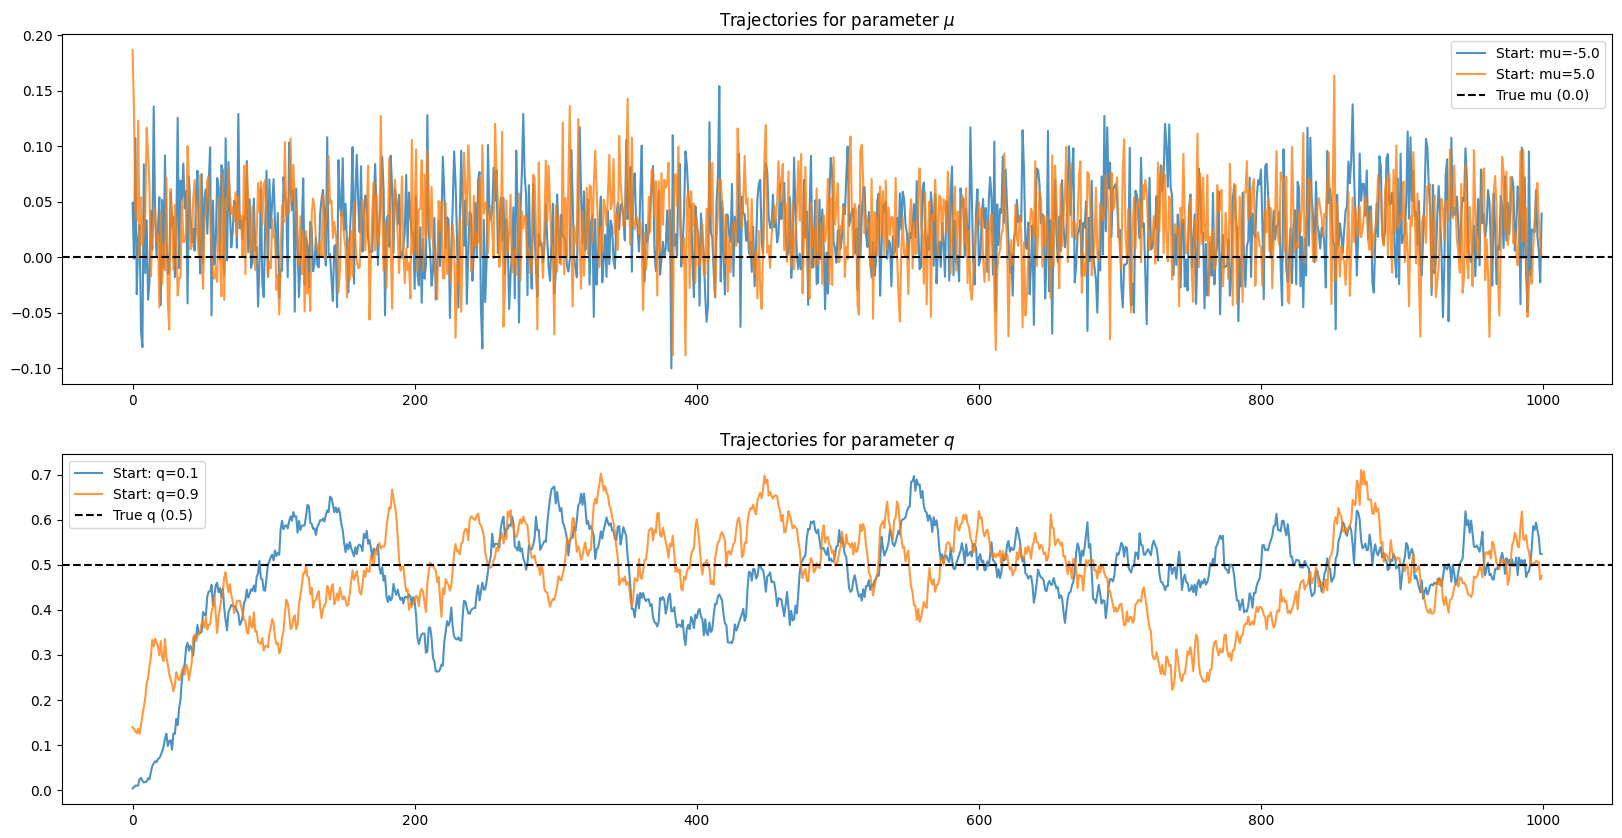

In [ ]:
# simulations and visualizations
num_iter = 1000

# starting from q_0 = 0.1, mu_0 = -5.0 /// q_0 = 0.9, mu_0 = 5.0
mu_trace1, q_trace1 = gibbs_sampler(y, sigma2, init_mu=-5.0, init_q=0.1, num_iter=num_iter)
mu_trace2, q_trace2 = gibbs_sampler(y, sigma2, init_mu=5.0, init_q=0.9, num_iter=num_iter)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

ax1.plot(mu_trace1, label='Start: mu=-5.0', alpha=0.8)
ax1.plot(mu_trace2, label='Start: mu=5.0', alpha=0.8)
ax1.axhline(true_mu, color='black', linestyle='--', label='True mu (0.0)')
ax1.set_title("Trajectories for parameter $\mu$")
ax1.legend()

ax2.plot(q_trace1, label='Start: q=0.1', alpha=0.8)
ax2.plot(q_trace2, label='Start: q=0.9', alpha=0.8)
ax2.axhline(true_q, color='black', linestyle='--', label=f'True q ({true_q})')
ax2.set_title("Trajectories for parameter $q$")
ax2.legend()

plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20262/1142816369.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Trajectories for parameter $\mu$")


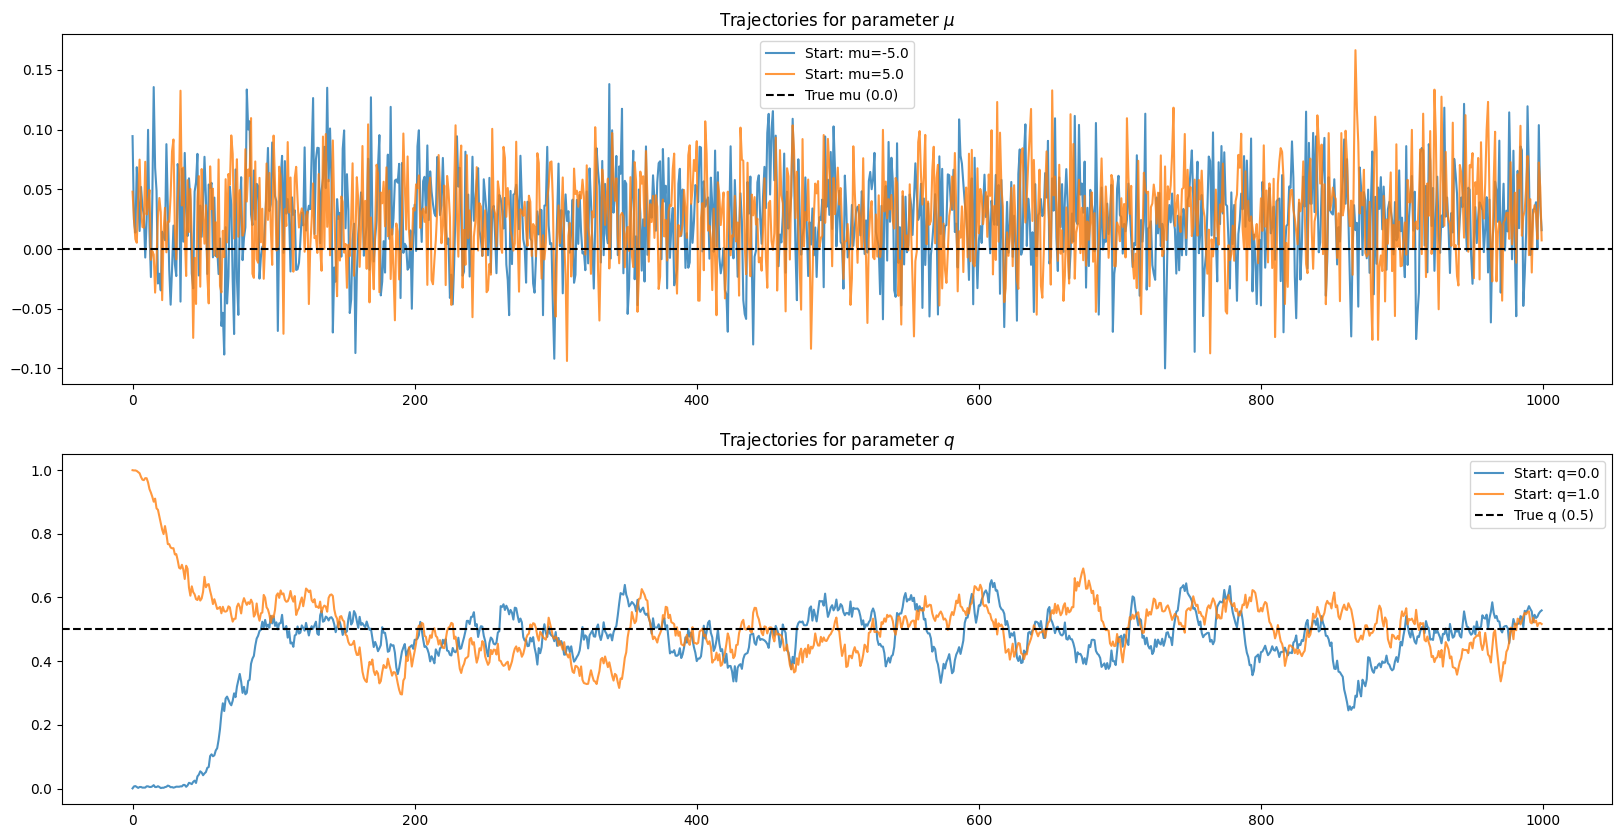

In [ ]:
# simulations and visualizations
num_iter = 1000

# starting from q_0 = 0.0, mu_0 = -5.0 /// q_0 = 1.0, mu_0 = 5.0
mu_trace1, q_trace1 = gibbs_sampler(y, sigma2, init_mu=-5.0, init_q=0, num_iter=num_iter)
mu_trace2, q_trace2 = gibbs_sampler(y, sigma2, init_mu=5.0, init_q=1, num_iter=num_iter)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

ax1.plot(mu_trace1, label='Start: mu=-5.0', alpha=0.8)
ax1.plot(mu_trace2, label='Start: mu=5.0', alpha=0.8)
ax1.axhline(true_mu, color='black', linestyle='--', label='True mu (0.0)')
ax1.set_title("Trajectories for parameter $\mu$")
ax1.legend()

ax2.plot(q_trace1, label='Start: q=0.0', alpha=0.8)
ax2.plot(q_trace2, label='Start: q=1.0', alpha=0.8)
ax2.axhline(true_q, color='black', linestyle='--', label=f'True q ({true_q})')
ax2.set_title("Trajectories for parameter $q$")
ax2.legend()

plt.show()

## $q=1, \mu=0, σ^2 = 2$

In [ ]:
# generating data
np.random.seed(42)
n = 1000
true_mu = 0.0
true_q = 1
sigma2 = 2.0

# sampling assignment to one of the normal distribution
true_Z = np.random.binomial(1, true_q, size=n)

# sampling with regard to above assignment
y = np.where(true_Z == 1,
             np.random.normal(true_mu, 1, size=n),
             np.random.normal(true_mu, np.sqrt(sigma2), size=n))

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20262/1312830159.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Trajectories for parameter $\mu$")


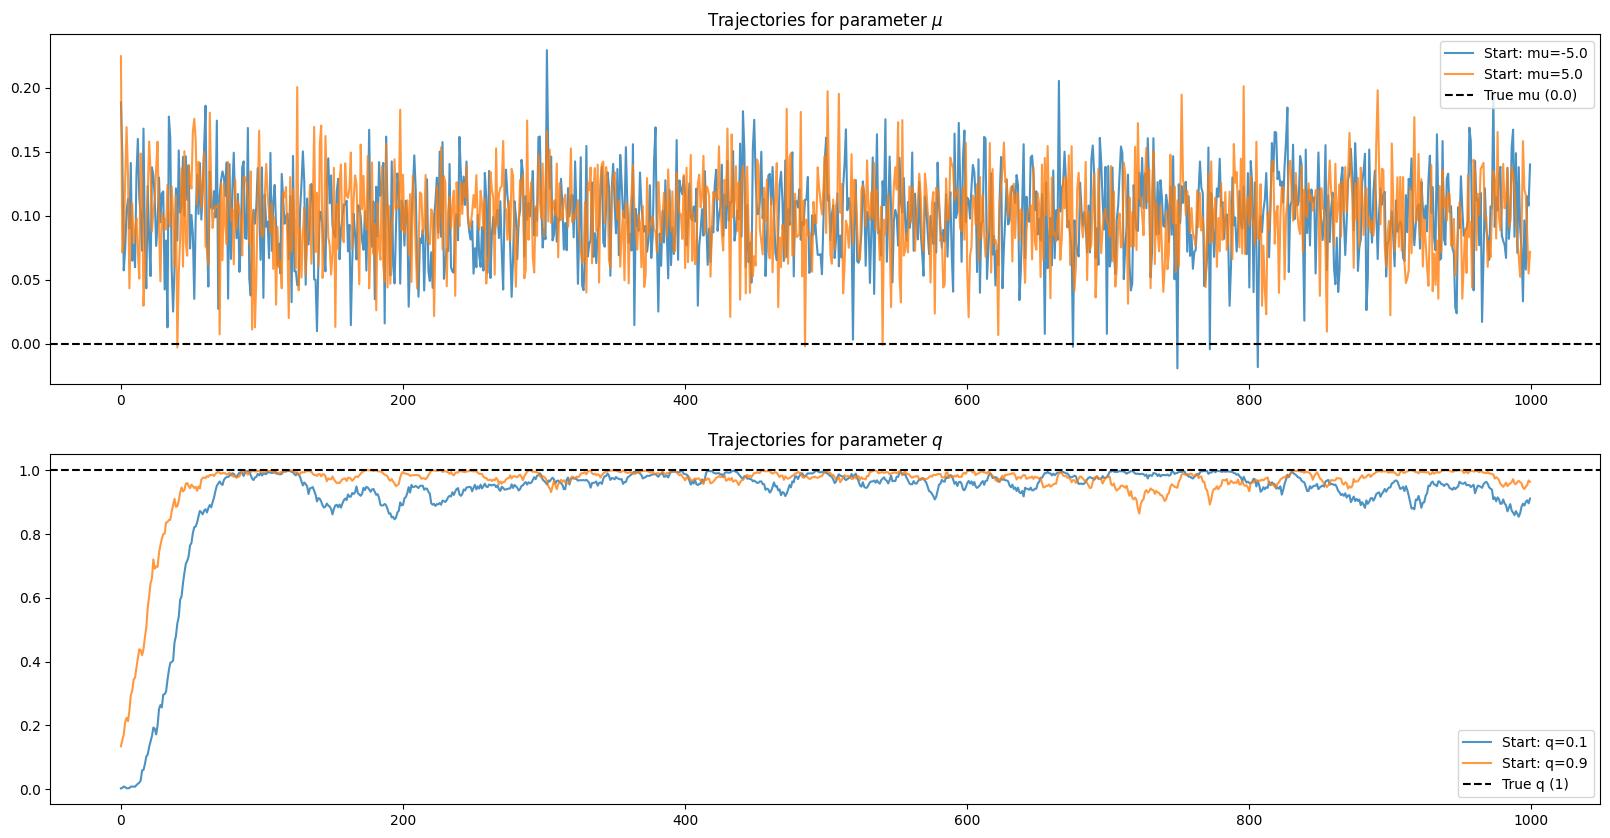

In [ ]:
# simulations and visualizations
num_iter = 1000

# starting from q_0 = 0.1, mu_0 = -5.0 /// q_0 = 0.9, mu_0 = 5.0
mu_trace1, q_trace1 = gibbs_sampler(y, sigma2, init_mu=-5.0, init_q=0.1, num_iter=num_iter)
mu_trace2, q_trace2 = gibbs_sampler(y, sigma2, init_mu=5.0, init_q=0.9, num_iter=num_iter)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

ax1.plot(mu_trace1, label='Start: mu=-5.0', alpha=0.8)
ax1.plot(mu_trace2, label='Start: mu=5.0', alpha=0.8)
ax1.axhline(true_mu, color='black', linestyle='--', label='True mu (0.0)')
ax1.set_title("Trajectories for parameter $\mu$")
ax1.legend()

ax2.plot(q_trace1, label='Start: q=0.1', alpha=0.8)
ax2.plot(q_trace2, label='Start: q=0.9', alpha=0.8)
ax2.axhline(true_q, color='black', linestyle='--', label=f'True q ({true_q})')
ax2.set_title("Trajectories for parameter $q$")
ax2.legend()

plt.show()

In [ ]:
print(np.mean(y))

0.09889581794849281


## $q=0, \mu=0, σ^2 = 2$

In [ ]:
# generating data
np.random.seed(42)
n = 1000
true_mu = 0.0
true_q = 0
sigma2 = 2.0

# sampling assignment to one of the normal distribution
true_Z = np.random.binomial(1, true_q, size=n)

# sampling with regard to above assignment
y = np.where(true_Z == 1,
             np.random.normal(true_mu, 1, size=n),
             np.random.normal(true_mu, np.sqrt(sigma2), size=n))

<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:13: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_20262/1312830159.py:13: SyntaxWarning: invalid escape sequence '\m'
  ax1.set_title("Trajectories for parameter $\mu$")


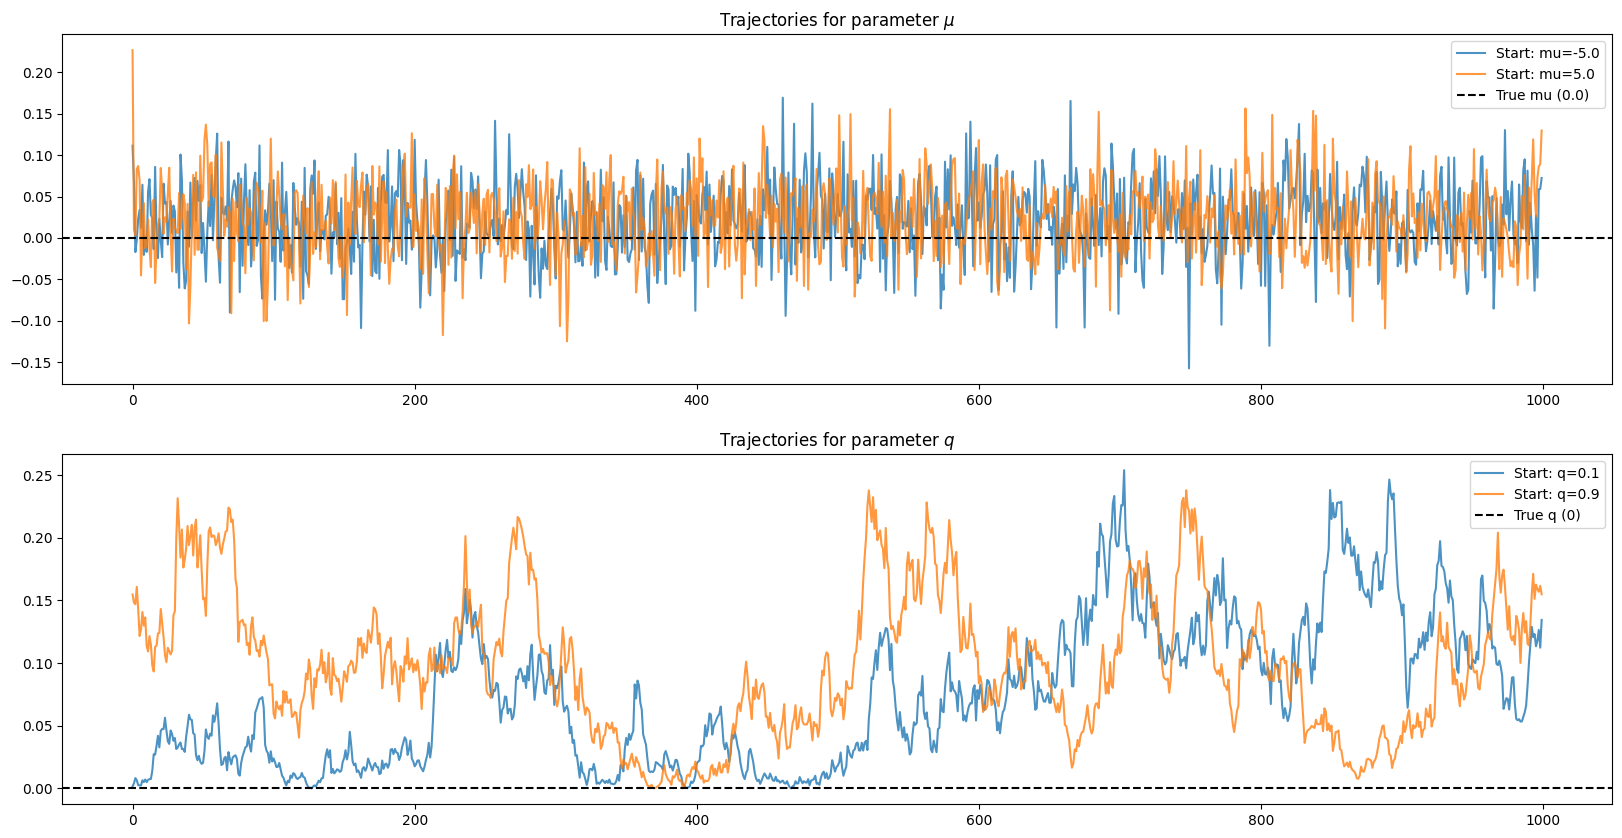

In [ ]:
# simulations and visualizations
num_iter = 1000

# starting from q_0 = 0.1, mu_0 = -5.0 /// q_0 = 0.9, mu_0 = 5.0
mu_trace1, q_trace1 = gibbs_sampler(y, sigma2, init_mu=-5.0, init_q=0.1, num_iter=num_iter)
mu_trace2, q_trace2 = gibbs_sampler(y, sigma2, init_mu=5.0, init_q=0.9, num_iter=num_iter)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 10))

ax1.plot(mu_trace1, label='Start: mu=-5.0', alpha=0.8)
ax1.plot(mu_trace2, label='Start: mu=5.0', alpha=0.8)
ax1.axhline(true_mu, color='black', linestyle='--', label='True mu (0.0)')
ax1.set_title("Trajectories for parameter $\mu$")
ax1.legend()

ax2.plot(q_trace1, label='Start: q=0.1', alpha=0.8)
ax2.plot(q_trace2, label='Start: q=0.9', alpha=0.8)
ax2.axhline(true_q, color='black', linestyle='--', label=f'True q ({true_q})')
ax2.set_title("Trajectories for parameter $q$")
ax2.legend()

plt.show()

In [ ]:
print(np.mean(y))

0.01954437975646762
